# Exploratory Data Analysis(EDA)-tmdb_tn_merged_cleaned

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
tmdb_merged = pd.read_csv("tmdb_tn_merged_cleaned.csv")

In [8]:
tmdb_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           4869 non-null   int64  
 1   release_date                 4869 non-null   object 
 2   title                        4869 non-null   object 
 3   production_budget            4869 non-null   int64  
 4   domestic_gross               4869 non-null   int64  
 5   worldwide_gross              4869 non-null   int64  
 6   release_year                 4869 non-null   int64  
 7   release_month_x              4869 non-null   int64  
 8   Profit                       4869 non-null   int64  
 9   ROI                          4869 non-null   float64
 10  Domestic_vs_Worldwide_Ratio  4520 non-null   float64
 11  Release_Month                4869 non-null   int64  
 12  Day_of_Week                  4869 non-null   object 
dtypes: float64(2), int

In [9]:
tmdb_merged.columns

Index(['id', 'release_date', 'title', 'production_budget', 'domestic_gross',
       'worldwide_gross', 'release_year', 'release_month_x', 'Profit', 'ROI',
       'Domestic_vs_Worldwide_Ratio', 'Release_Month', 'Day_of_Week'],
      dtype='object')

In [10]:
tmdb_merged.head(5)

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,release_year,release_month_x,Profit,ROI,Domestic_vs_Worldwide_Ratio,Release_Month,Day_of_Week
0,32,2008-02-14,The Spiderwick Chronicles,92500000,71195053,162839667,2008,2,70339667,0.760429,0.437210,2,Thursday
1,35,2004-04-09,The Alamo,92000000,22406362,23911362,2004,4,-68088638,-0.740094,0.937059,4,Friday
2,36,1995-12-22,Cutthroat Island,92000000,10017322,18517322,1995,12,-73482678,-0.798725,0.540970,12,Friday
3,37,2013-12-25,The Secret Life of Walter Mitty,91000000,58236838,187861183,2013,12,96861183,1.064409,0.309999,12,Wednesday
4,50,2008-08-13,Tropic Thunder,90000000,110515313,191145256,2008,8,101145256,1.123836,0.578175,8,Wednesday


In [39]:
tmdb_merged.isnull().sum()

id                               0
release_date                     0
title                            0
production_budget                0
domestic_gross                   0
worldwide_gross                  0
release_year                     0
release_month_x                  0
profit                           0
roi                              0
domestic_vs_worldwide_ratio    349
release_month                    0
day_of_week                      0
dtype: int64

In [11]:
tmdb_merged.tail(5)

,id,release_date,title,production_budget,domestic_gross,worldwide_gross,release_year,release_month_x,Profit,ROI,Domestic_vs_Worldwide_Ratio,Release_Month,Day_of_Week
4864,78,2018-12-31,Red 11,7000,0,0,2018,12,-7000,-1.000000,NaN,12,Monday
4865,79,1999-04-02,Following,6000,48482,240495,1999,4,234495,39.082500,0.201593,4,Friday
4866,80,2005-07-13,Return to the Land of Wonders,5000,1338,1338,2005,7,-3662,-0.732400,1.000000,7,Wednesday
4867,81,2015-09-29,A Plague So Pleasant,1400,0,0,2015,9,-1400,-1.000000,NaN,9,Tuesday
4868,82,2005-08-05,My Date With Drew,1100,181041,181041,2005,8,179941,163.582727,1.000000,8,Friday


1.Univariate Analysis
We'll look at the distribution and statistics for individual variables, especially:

- production_budget

- domestic_gross

- worldwide_gross

- ROI

- Profit
- Release_Month

- Day_of_Week

In [75]:
# Columns to analyze
num_cols = ['production_budget', 'domestic_gross', 'worldwide_gross', 'roi', 'profit', 'release_month_x']
cat_cols = ['day_of_week']

In [77]:
# Display descriptive statistics
print("Descriptive Statistics (Numerical):")
print(tmdb_merged[num_cols].describe())

print("\nDay_of_Week Value Counts:")
print(tmdb_merged['day_of_week'].value_counts())

Descriptive Statistics (Numerical):
       production_budget  domestic_gross  worldwide_gross          roi  \
count       4.869000e+03    4.869000e+03     4.869000e+03  4869.000000   
mean        2.126697e+07    2.301173e+07     4.250184e+07     2.300585   
std         2.097487e+07    2.784170e+07     5.346004e+07    13.485967   
min         1.100000e+03    0.000000e+00     0.000000e+00    -1.000000   
25%         4.900000e+06    6.237910e+05     2.301777e+06    -0.659362   
50%         1.500000e+07    1.201737e+07     2.000561e+07     0.362420   
75%         3.000000e+07    3.644344e+07     6.259916e+07     2.030274   
max         9.250000e+07    1.280678e+08     2.406476e+08   430.517853   

             profit  release_month_x  
count  4.869000e+03      4869.000000  
mean   2.123487e+07         7.054837  
std    4.409219e+07         3.511466  
min   -9.000000e+07         1.000000  
25%   -3.477072e+06         4.000000  
50%    3.475778e+06         8.000000  
75%    3.417045e+07     

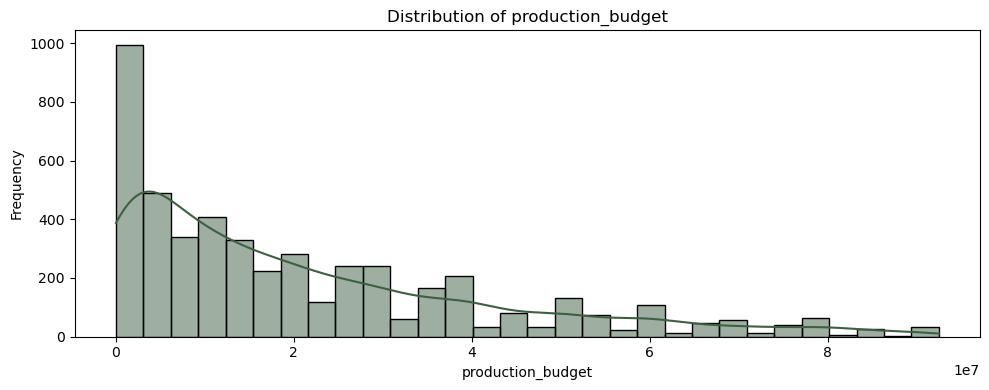

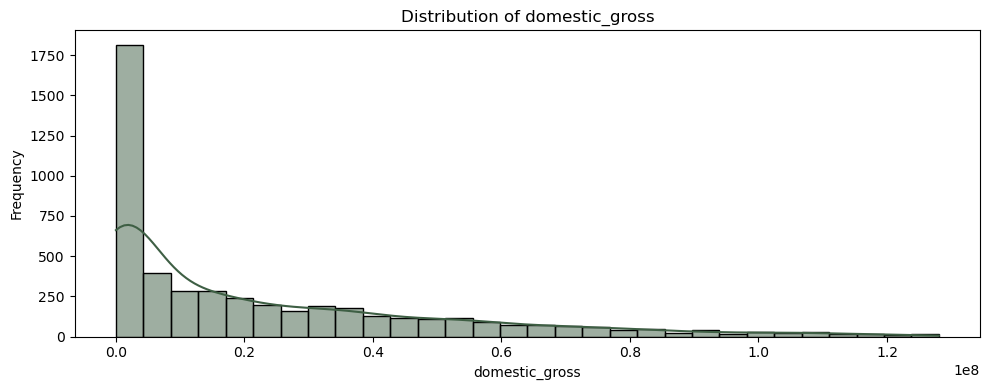

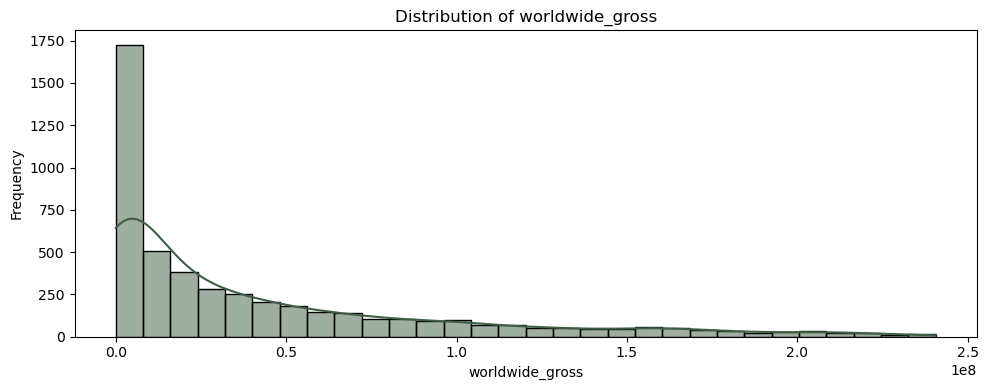

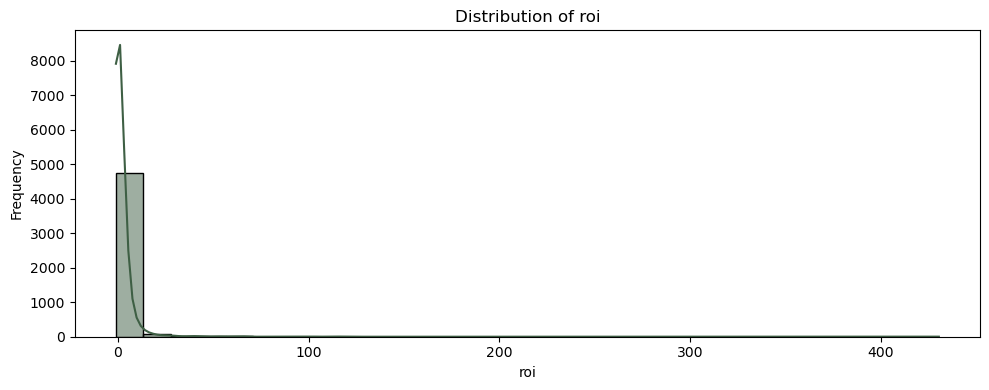

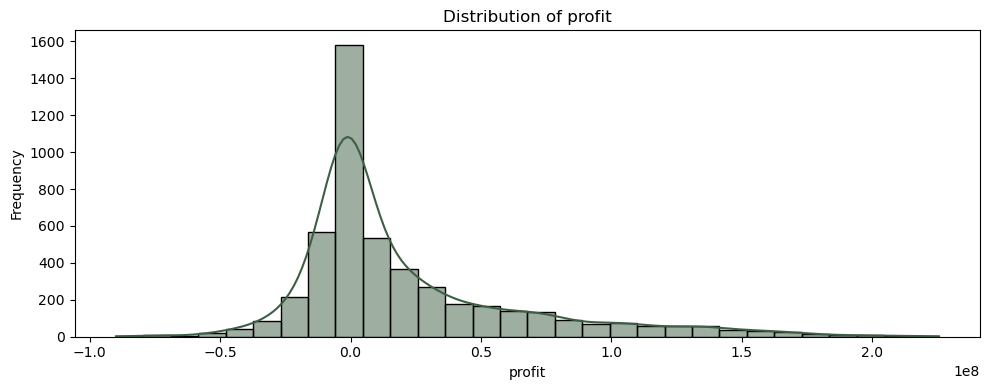

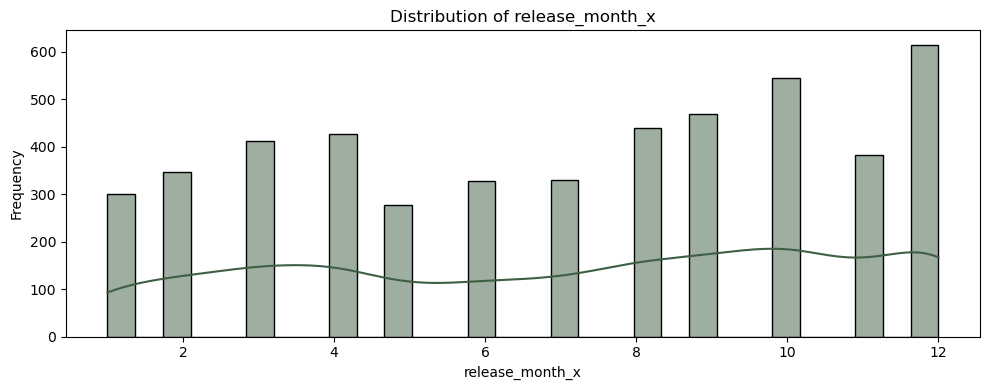

In [79]:
# Plotting histograms for numeric features
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(tmdb_merged[col], kde=True, bins=30, color='#3E5F44')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

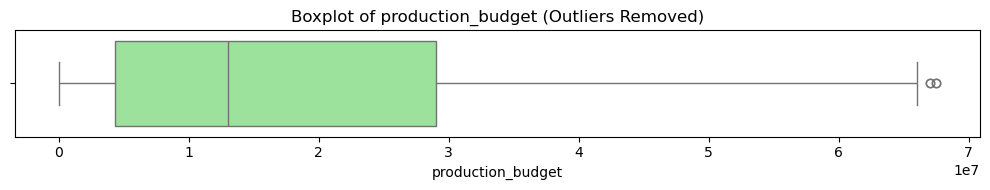

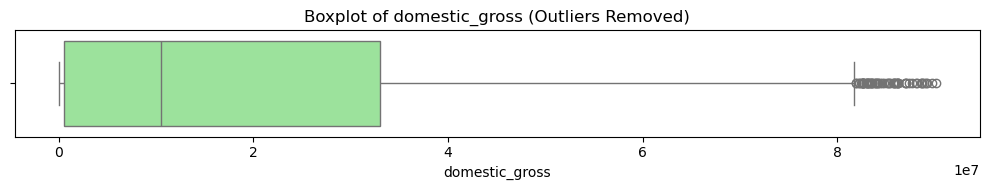

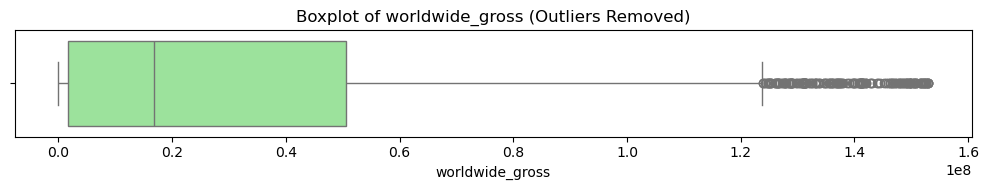

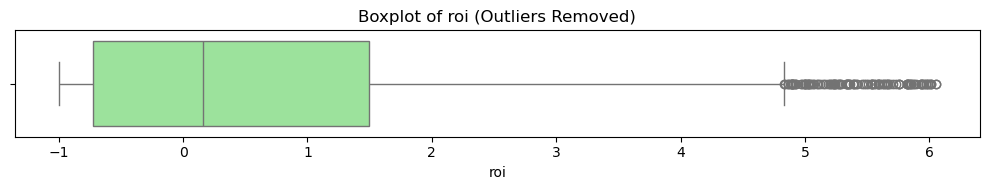

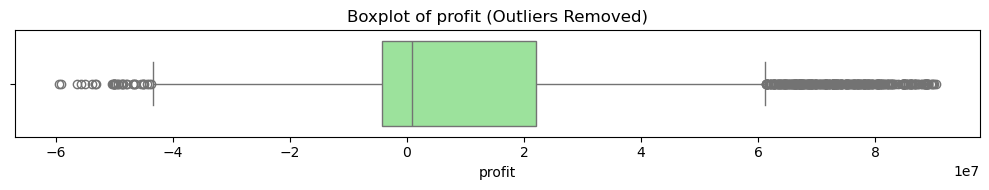

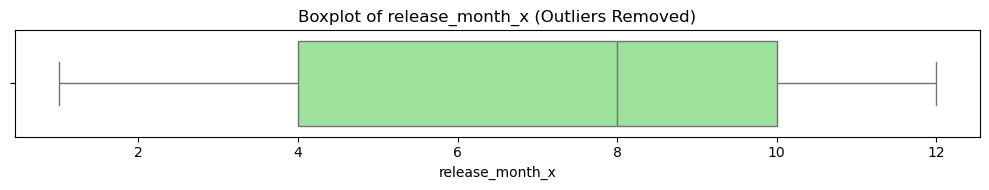

In [82]:
# Boxplots for numeric features (to detect outliers and remove outliers)
for col in num_cols:
    # Calculate Q1 and Q3
    Q1 = tmdb_merged[col].quantile(0.25)
    Q3 = tmdb_merged[col].quantile(0.75)
    IQR = Q3 - Q1

    # Filter out the outliers
    filtered_data = tmdb_merged[(tmdb_merged[col] >= Q1 - 1.5 * IQR) & (tmdb_merged[col] <= Q3 + 1.5 * IQR)]

    # Plot
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=filtered_data[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (Outliers Removed)')
    plt.tight_layout()
    plt.show()

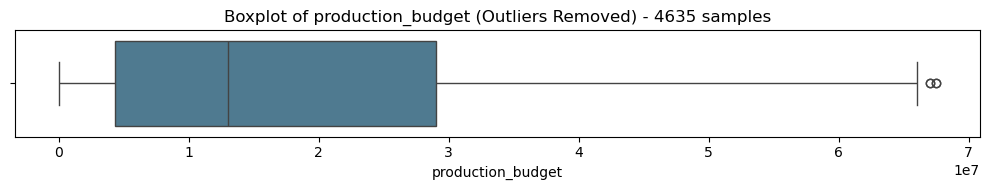

production_budget: Removed 234 outliers


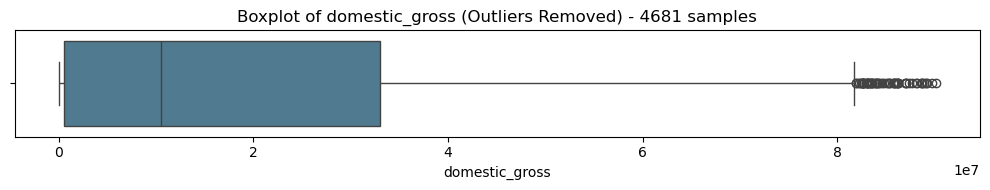

domestic_gross: Removed 188 outliers


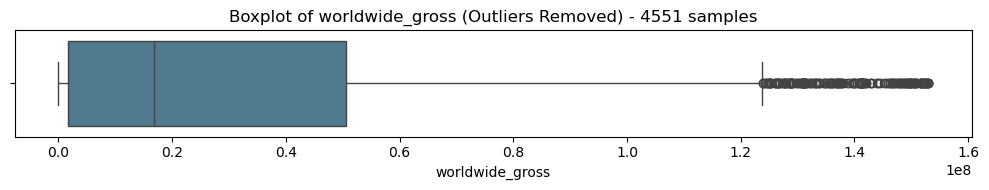

worldwide_gross: Removed 318 outliers


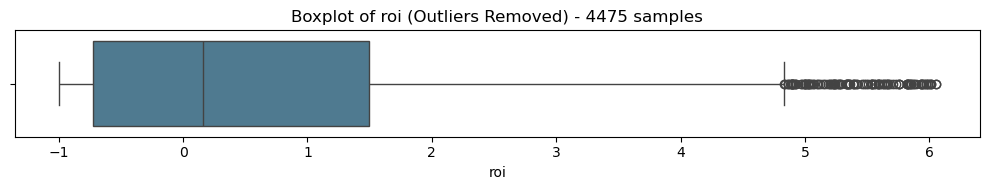

roi: Removed 394 outliers


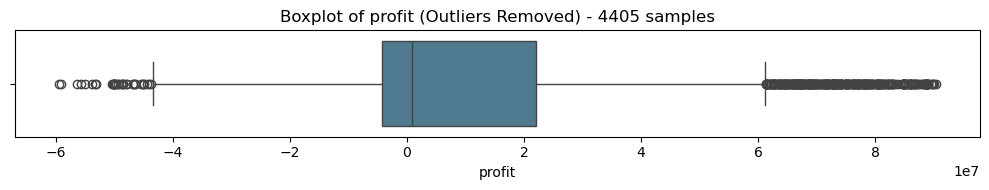

profit: Removed 464 outliers


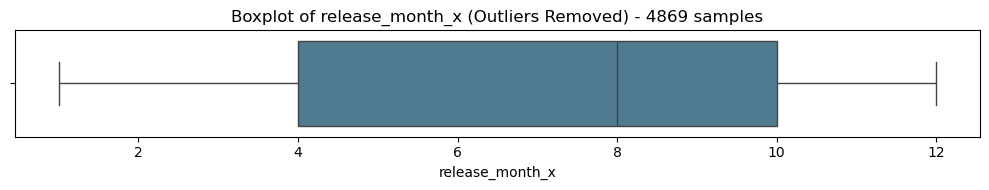

release_month_x: Removed 0 outliers


In [87]:
for col in num_cols:
    # Calculating Q1 and Q3
    Q1 = tmdb_merged[col].quantile(0.25)
    Q3 = tmdb_merged[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Filter out the outliers
    mask = (tmdb_merged[col] >= Q1 - 1.5 * IQR) & (tmdb_merged[col] <= Q3 + 1.5 * IQR)
    filtered_data = tmdb_merged[mask]
    
    # Checking if we have data left after filtering
    if len(filtered_data) > 0:
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=filtered_data[col], color='#447D9B')
        plt.title(f'Boxplot of {col} (Outliers Removed) - {len(filtered_data)} samples')
        plt.tight_layout()
        plt.show()
        print(f"{col}: Removed {len(tmdb_merged) - len(filtered_data)} outliers")
    else:
        print(f"{col}: All data points were considered outliers!")

C:\Users\Ben\AppData\Local\Temp\ipykernel_32292\27299683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week', data=tmdb_merged, order=tmdb_merged['day_of_week'].value_counts().index, palette='Set2')


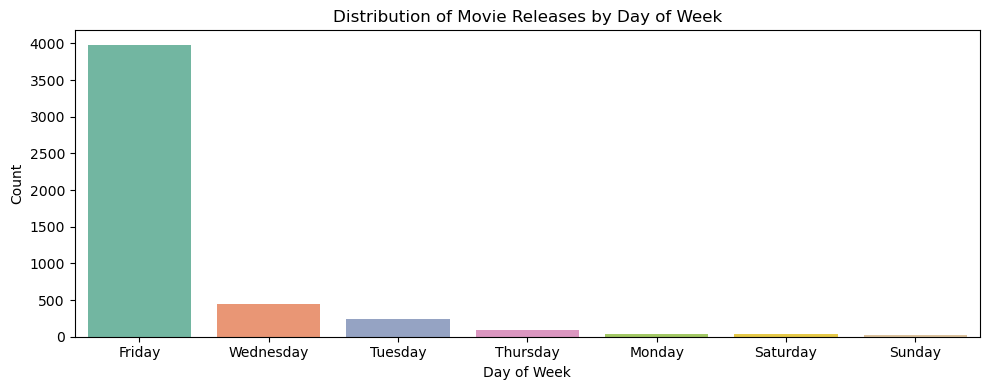

In [86]:
# Bar plot for Day_of_Week (categorical)
plt.figure(figsize=(10, 4))
sns.countplot(x='day_of_week', data=tmdb_merged, order=tmdb_merged['day_of_week'].value_counts().index, palette='Set2')
plt.title('Distribution of Movie Releases by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

2. Bivariate Analysis We’ll analyze pairwise relationships like:
- production_budget vs ROI

- production_budget vs Profit

- ROI vs Profit

- Release_Month vs worldwide_gross

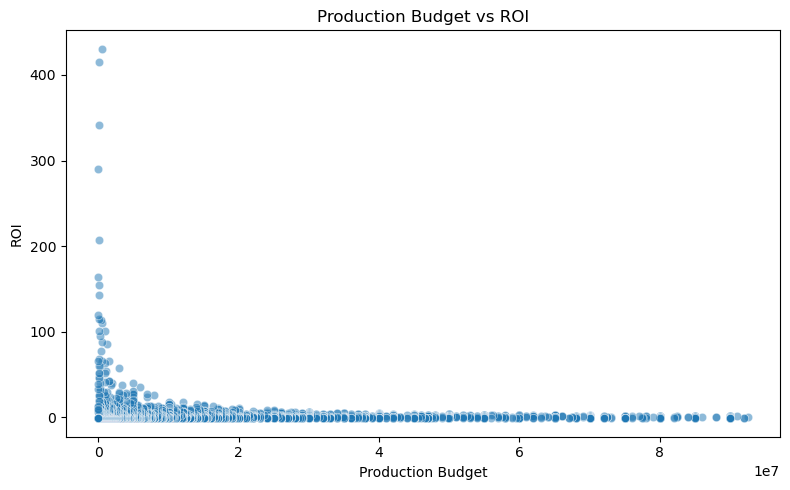

In [49]:
# 1. production_budget vs ROI
plt.figure(figsize=(8, 5))
sns.scatterplot(x='production_budget', y='roi', data=tmdb_merged, alpha=0.5)
plt.title('Production Budget vs ROI')
plt.xlabel('Production Budget')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()

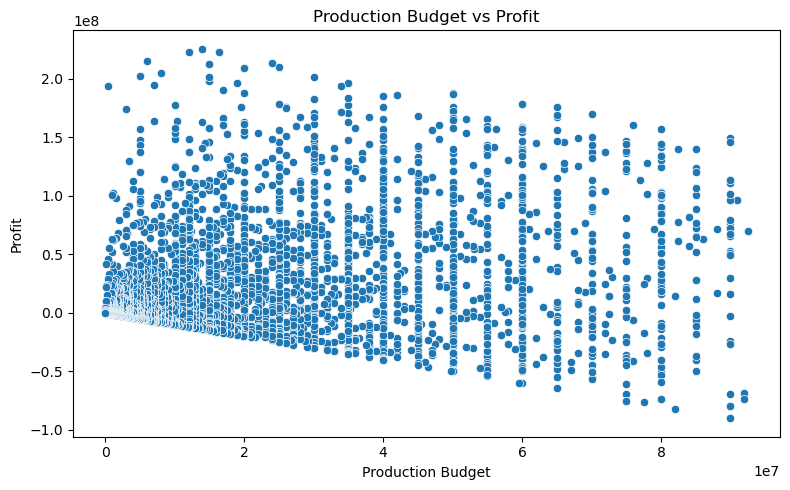

In [54]:
# 2. production_budget vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='production_budget', y='profit', data=tmdb_merged)
plt.title('Production Budget vs Profit')
plt.xlabel('Production Budget')
plt.ylabel('Profit')
plt.tight_layout()
plt.show();

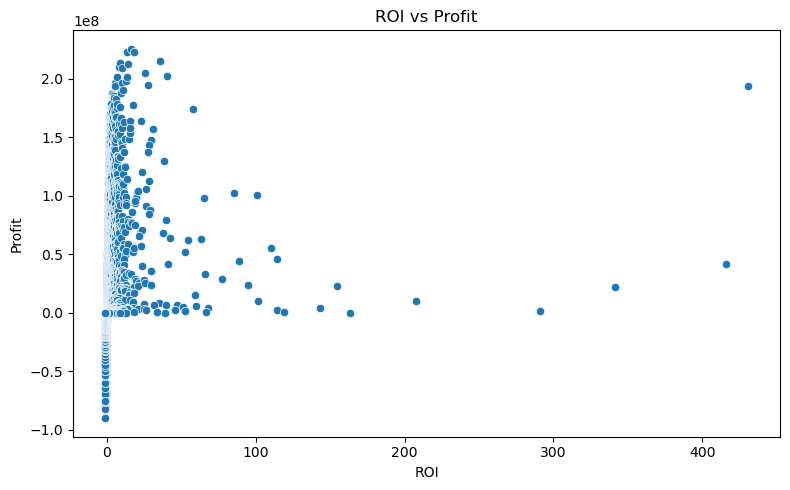

In [57]:
# 3. ROI vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='roi', y='profit', data=tmdb_merged)
plt.title('ROI vs Profit')
plt.xlabel('ROI')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

C:\Users\Ben\AppData\Local\Temp\ipykernel_32292\360337774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='release_month_x', y='worldwide_gross', data=tmdb_merged, palette='pastel')


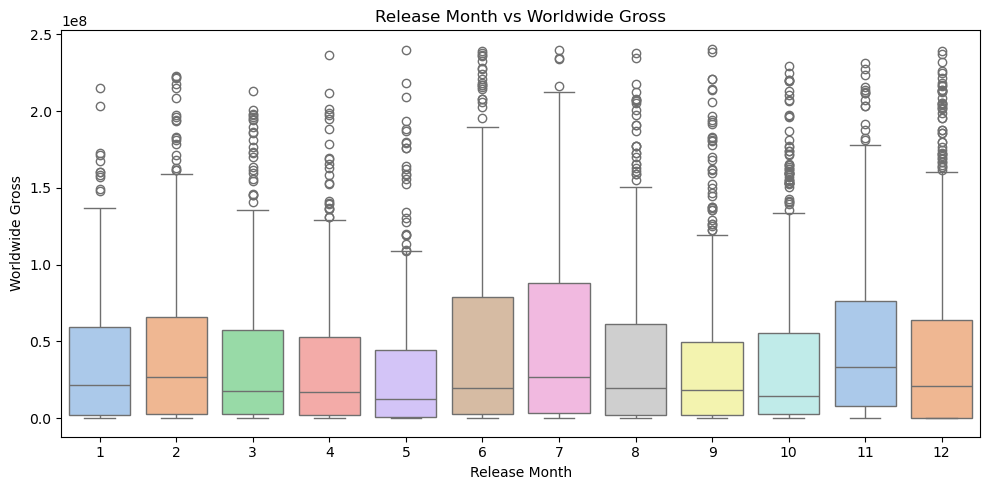

In [89]:
# 4. Release_Month vs Worldwide Gross (using boxplot to show trends)
plt.figure(figsize=(10, 5))
sns.boxplot(x='release_month_x', y='worldwide_gross', data=tmdb_merged, palette='pastel')
plt.title('Release Month vs Worldwide Gross')
plt.xlabel('Release Month')
plt.ylabel('Worldwide Gross')
plt.tight_layout()
plt.show()

In [66]:
# Print correlation values
corrs = tmdb_merged[['production_budget', 'roi', 'profit', 'worldwide_gross', 'release_month_x']].corr()
print("Selected Correlation Matrix:")
print(corrs[['production_budget', 'roi', 'profit']].round(2))

Selected Correlation Matrix:
                   production_budget   roi  profit
production_budget               1.00 -0.10    0.26
roi                            -0.10  1.00    0.18
profit                          0.26  0.18    1.00
worldwide_gross                 0.60  0.11    0.93
release_month_x                 0.04 -0.01    0.03


Observations
- Scatter plots show the trend and spread between numerical pairs.
- Boxplot for Release_Month vs worldwide_gross reveals seasonal performance.
- The correlation matrix provides numeric strength of linear relationships.

3. Multivariate Analysis
- We’ll explore how multiple features interact together, e.g
- Correlation heatmaps among numeric variables.

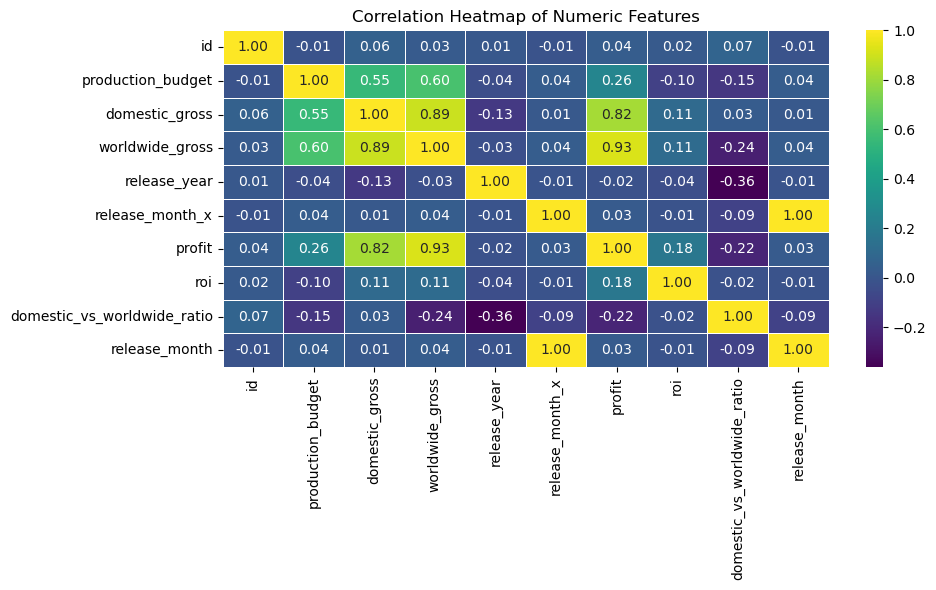

In [67]:
# Select only numeric columns
numeric_cols = tmdb_merged.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = tmdb_merged[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

In [ ]:
# The above  visualizes linear relationships across numeric features

Future plans include using Linear Regression to predict Profit using:

production_budget
Release_Month
Day_of_Week

####END 